# Predicción del Índice de Seguridad por coordenadas y hora

Objetivo: una función **(latitud, longitud, hora) → SI** para usar como peso en el algoritmo multiobjetivo.

- La ciudad se divide en **celdas de 500 m** y el día en **24 horas**.
- El SI de cada celda-hora usa la misma fórmula que Crime_Population2: `SI = N[ALPHA·violentos + (1−ALPHA)·robos]`. La diferencia es que aquí los delitos se cuentan **por celda** (todas tienen la misma área, así que equivale a delitos por km²), no por residente. Esto evita inflar el riesgo en zonas comerciales con pocos habitantes.
- Un modelo aprende el SI a partir de (lat, lon, hora). Luego se prueba si el SI **predicho** anticipa el riesgo futuro mejor que el SI **calculado** directamente.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_predict

ALPHA = 0.7        # mismo peso que Crime_Population2
PERCENTIL = 0.99   # tope de la normalizacion N
TAM_CELDA = 0.5    # km

# proyeccion local a km (a 20.6 grados de latitud): suficiente para una ciudad
LAT0, LON0 = 20.6, -103.4
KM_POR_GRADO_LAT, KM_POR_GRADO_LON = 110.7, 104.2

AZUL, TINTA, TINTA_2, FONDO, REJILLA = "#2a78d6", "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"

delitos_violentos = ["Violencia familiar", "Lesiones dolosas", "Abuso sexual infantil",
                     "Homicidio doloso", "Violacion", "Feminicidio"]

d = pd.read_csv("Crime_Population.csv", usecols=["delito", "x", "y", "hora", "año"])
n_total = len(d)
d = d.dropna(subset=["x", "y", "hora"])
d["hora"] = d["hora"].astype(int)
d["n_violence"] = d["delito"].isin(delitos_violentos).astype(int)
d["n_property"] = d["delito"].str.startswith("Robo").astype(int)
d["ix"] = ((d["x"] - LON0) * KM_POR_GRADO_LON // TAM_CELDA).astype(int)
d["iy"] = ((d["y"] - LAT0) * KM_POR_GRADO_LAT // TAM_CELDA).astype(int)

# malla: todas las celdas con al menos un delito (la huella urbana) x 24 horas.
# Las horas sin delitos entran en cero: si no, el modelo nunca veria momentos tranquilos
celdas = d[["ix", "iy"]].drop_duplicates()
malla = celdas.merge(pd.DataFrame({"hora": range(24)}), how="cross")
malla["lon"] = LON0 + (malla["ix"] + 0.5) * TAM_CELDA / KM_POR_GRADO_LON
malla["lat"] = LAT0 + (malla["iy"] + 0.5) * TAM_CELDA / KM_POR_GRADO_LAT

print(f"Delitos con coordenadas y hora: {len(d):,} de {n_total:,}")
print(f"{len(celdas):,} celdas x 24 horas = {len(malla):,} celda-hora")

Delitos con coordenadas y hora: 273,204 de 306,142
4,342 celdas x 24 horas = 104,208 celda-hora


In [4]:
def calcular_si(sub):
    """SI de cada celda-hora de la malla con los delitos de `sub`."""
    c = sub.groupby(["ix", "iy", "hora"])[["n_violence", "n_property"]].sum()
    c = c.reindex(pd.MultiIndex.from_frame(malla[["ix", "iy", "hora"]]), fill_value=0)
    x = ALPHA * c["n_violence"].to_numpy() + (1 - ALPHA) * c["n_property"].to_numpy()
    tope = np.quantile(x, PERCENTIL)
    return 100 * np.clip(x, None, tope) / tope   # el minimo es 0: celdas-hora sin delitos


malla["SI"] = calcular_si(d)
# para la prueba temporal: se calcula con el pasado y se evalua contra el futuro
malla["SI_2020_23"] = calcular_si(d[d["año"] <= 2023])
malla["SI_2024_26"] = calcular_si(d[d["año"] >= 2024])

# hora ciclica: las 23 y las 0 estan juntas
malla["hora_sin"] = np.sin(2 * np.pi * malla["hora"] / 24)
malla["hora_cos"] = np.cos(2 * np.pi * malla["hora"] / 24)
features = ["lat", "lon", "hora", "hora_sin", "hora_cos"]
X = malla[features]

print(f"SI: mediana {malla['SI'].median():.1f}, media {malla['SI'].mean():.1f}, "
      f"{(malla['SI'] == 0).mean():.0%} de celda-hora en cero")

SI: mediana 3.8, media 14.5, 44% de celda-hora en cero


## 1. ¿Qué tan bien se predice el SI con coordenadas y hora?

Dos validaciones:
- **Por celda**: el modelo no vio esa celda, pero sí a sus vecinas. Es el caso de uso real: estimar el riesgo de un punto de la ciudad conociendo su zona.
- **Por zona de 3 km**: se deja fuera un bloque completo de la ciudad. Es la prueba más estricta.

In [5]:
def hgb():
    # perdida Poisson: el SI viene de conteos de delitos (muchos ceros, sin negativos)
    return HistGradientBoostingRegressor(loss="poisson", max_iter=400, learning_rate=0.05,
                                         min_samples_leaf=40, random_state=0)


def bosque():
    return RandomForestRegressor(n_estimators=200, min_samples_leaf=20, max_features=0.6,
                                 n_jobs=-1, random_state=0)


grupo_celda = malla["ix"].astype(str) + "_" + malla["iy"].astype(str)
bloque = int(3 / TAM_CELDA)
grupo_zona = (malla["ix"] // bloque).astype(str) + "_" + (malla["iy"] // bloque).astype(str)
cv = GroupKFold(n_splits=5)

modelos = {
    "Solo hora (baseline)": (hgb, ["hora"]),
    "Gradient Boosting":    (hgb, features),
    "Random Forest":        (bosque, features),
}
filas = []
for nombre, (fabrica, columnas) in modelos.items():
    for validacion, grupos in (("por celda", grupo_celda), ("por zona 3 km", grupo_zona)):
        pred = cross_val_predict(fabrica(), malla[columnas], malla["SI"], groups=grupos, cv=cv)
        filas.append({"Modelo": nombre, "Validacion": validacion,
                      "R2": r2_score(malla["SI"], pred),
                      "MAE": mean_absolute_error(malla["SI"], pred),
                      "Spearman": spearmanr(malla["SI"], pred)[0]})
pd.DataFrame(filas).round(3)

,Modelo,Validacion,R2,MAE,Spearman
0,Solo hora (baseline),por celda,0.056,15.373,0.190
1,Solo hora (baseline),por zona 3 km,0.052,15.393,0.181
2,Gradient Boosting,por celda,0.527,9.487,0.711
3,Gradient Boosting,por zona 3 km,0.414,10.394,0.639
4,Random Forest,por celda,0.524,9.578,0.707
5,Random Forest,por zona 3 km,0.428,10.481,0.639


## 2. ¿Conviene predecir o solo calcular?

La pregunta clave para usarlo como peso: **¿qué anticipa mejor el riesgo futuro?** Se usa 2020–2023 para construir el índice y se compara contra lo que pasó en 2024–2026:

- **Calculado**: el SI de 2020–2023 tal cual.
- **Predicho**: el modelo entrenado con el SI de 2020–2023 (suaviza el ruido de celdas con pocos delitos).
- **Mezcla**: `w · calculado + (1 − w) · predicho`.

"Top 10% capturado": de las celdas-hora más peligrosas de 2024–2026, qué fracción el índice ya marcaba en su 10% más alto.

In [6]:
def top_capturado(indice, real, q=0.9):
    real_alto = real >= np.quantile(real, q)
    indice_alto = indice >= np.quantile(indice, q)
    return (real_alto & indice_alto).sum() / real_alto.sum()


pasado, futuro = malla["SI_2020_23"], malla["SI_2024_26"]
def predecir(modelo, datos):
    # la escala del SI es 0-100; el modelo puede pasarse un poco en los extremos
    return np.clip(modelo.predict(datos), 0, 100)


predicho_pasado = predecir(hgb().fit(X, pasado), X)

filas = []
for w in (1.0, 0.75, 0.5, 0.25, 0.0):
    indice = w * pasado + (1 - w) * predicho_pasado
    nombre = {1.0: "Calculado", 0.0: "Predicho"}.get(w, f"Mezcla {w:.0%} calculado")
    filas.append({"Indice": nombre, "peso calculado": w,
                  "R2 vs 2024-26": r2_score(futuro, indice),
                  "Spearman": spearmanr(futuro, indice)[0],
                  "Top 10% capturado": top_capturado(indice, futuro)})
tabla_temporal = pd.DataFrame(filas).round(3)
tabla_temporal

,Indice,peso calculado,R2 vs 2024-26,Spearman,Top 10% capturado
0,Calculado,1.00,0.221,0.599,0.446
1,Mezcla 75% calculado,0.75,0.339,0.624,0.442
2,Mezcla 50% calculado,0.50,0.405,0.635,0.452
3,Mezcla 25% calculado,0.25,0.420,0.637,0.447
4,Predicho,0.00,0.382,0.621,0.419


In [7]:
pasado.head()

0    22.835061
1     0.000000
2     0.000000
3    10.539259
4    12.295802
Name: SI_2020_23, dtype: float64

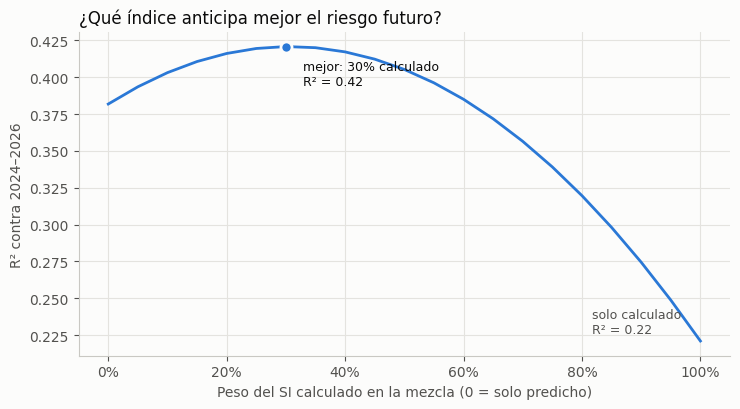

In [8]:
# R2 contra el futuro segun el peso del SI calculado en la mezcla
pesos = np.linspace(0, 1, 21)
r2_mezcla = [r2_score(futuro, w * pasado + (1 - w) * predicho_pasado) for w in pesos]
mejor = pesos[int(np.argmax(r2_mezcla))]

fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor=FONDO)
ax.set_facecolor(FONDO)
ax.plot(pesos, r2_mezcla, color=AZUL, linewidth=2)
ax.scatter([mejor], [max(r2_mezcla)], s=64, color=AZUL, edgecolor=FONDO, linewidth=2, zorder=3)
ax.annotate(f"mejor: {mejor:.0%} calculado\nR² = {max(r2_mezcla):.2f}", (mejor, max(r2_mezcla)),
            xytext=(12, -28), textcoords="offset points", color=TINTA, fontsize=9)
ax.annotate(f"solo calculado\nR² = {r2_mezcla[-1]:.2f}", (1, r2_mezcla[-1]),
            xytext=(-78, 6), textcoords="offset points", color=TINTA_2, fontsize=9)
ax.set_xlabel("Peso del SI calculado en la mezcla (0 = solo predicho)", color=TINTA_2)
ax.set_ylabel("R² contra 2024–2026", color=TINTA_2)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TINTA_2)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
for lado in ("left", "bottom"):
    ax.spines[lado].set_color("#c9c8c3")
ax.set_title("¿Qué índice anticipa mejor el riesgo futuro?", color=TINTA, fontsize=12, loc="left")
fig.tight_layout()
plt.show()

## 3. Índice final

El modelo final se entrena con **todos** los años, y el índice que se entrega es la mezcla `PESO_CALCULADO · SI calculado + (1 − PESO_CALCULADO) · SI predicho`. El peso se toma de la prueba anterior (es un solo parámetro, así que el sesgo por elegirlo con esa misma prueba es pequeño).

In [9]:
PESO_CALCULADO = 0.3

modelo_final = hgb().fit(X, malla["SI"])
malla["SI_predicho"] = predecir(modelo_final, X)
malla["SI_final"] = PESO_CALCULADO * malla["SI"] + (1 - PESO_CALCULADO) * malla["SI_predicho"]
malla[["SI", "SI_predicho", "SI_final"]].describe().round(2)

,SI,SI_predicho,SI_final
count,104208.00,104208.00,104208.00
mean,14.48,14.46,14.47
std,21.35,15.65,16.53
min,0.00,0.09,0.06
25%,0.00,2.90,2.39
50%,3.75,8.21,7.54
75%,21.25,20.88,21.09
max,100.00,100.00,100.00


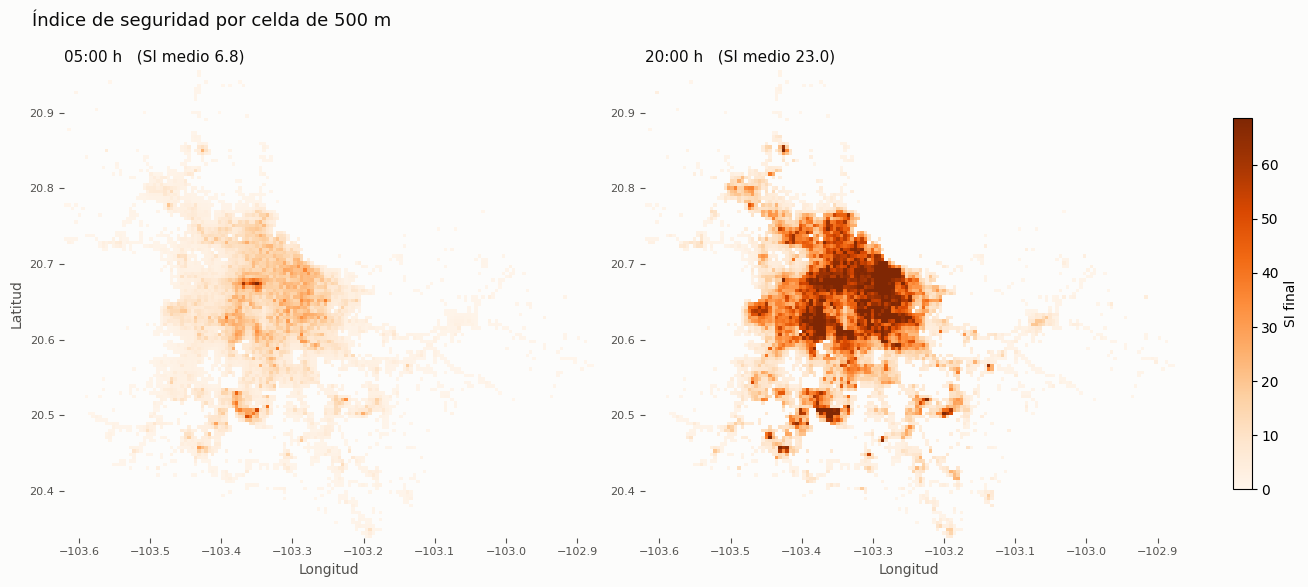

In [10]:
# mapa del SI final a dos horas del dia
horas_mapa = (5, 20)
ix0, iy0 = malla["ix"].min(), malla["iy"].min()
ancho, alto = malla["ix"].max() - ix0 + 1, malla["iy"].max() - iy0 + 1
extension = [LON0 + ix0 * TAM_CELDA / KM_POR_GRADO_LON, LON0 + (ix0 + ancho) * TAM_CELDA / KM_POR_GRADO_LON,
             LAT0 + iy0 * TAM_CELDA / KM_POR_GRADO_LAT, LAT0 + (iy0 + alto) * TAM_CELDA / KM_POR_GRADO_LAT]
tope_color = np.quantile(malla["SI_final"], 0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), facecolor=FONDO, layout="constrained")
for ax, h in zip(axes, horas_mapa):
    sub = malla[malla["hora"] == h]
    raster = np.full((alto, ancho), np.nan)
    raster[sub["iy"] - iy0, sub["ix"] - ix0] = sub["SI_final"]
    im = ax.imshow(raster, origin="lower", extent=extension, cmap="Oranges", vmin=0, vmax=tope_color,
                   interpolation="nearest")
    ax.set_aspect(KM_POR_GRADO_LAT / KM_POR_GRADO_LON)   # 1 km se ve igual en ambos ejes
    ax.set_facecolor(FONDO)
    ax.set_title(f"{h:02d}:00 h   (SI medio {sub['SI_final'].mean():.1f})", color=TINTA,
                 fontsize=11, loc="left")
    ax.tick_params(colors=TINTA_2, labelsize=8)
    for lado in ax.spines.values():
        lado.set_visible(False)
axes[0].set_ylabel("Latitud", color=TINTA_2)
for ax in axes:
    ax.set_xlabel("Longitud", color=TINTA_2)
fig.colorbar(im, ax=axes, shrink=0.7, label="SI final")
fig.suptitle("Índice de seguridad por celda de 500 m", color=TINTA, fontsize=13, x=0.02, ha="left")
plt.show()

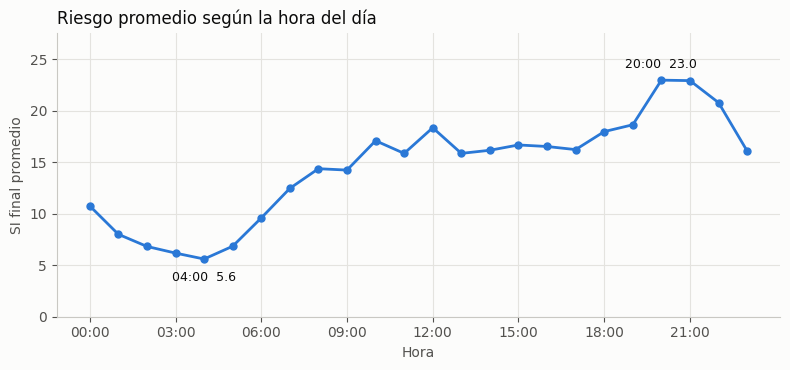

In [11]:
# perfil horario: SI promedio de la ciudad en cada hora
perfil = malla.groupby("hora")["SI_final"].mean()

fig, ax = plt.subplots(figsize=(8, 3.8), facecolor=FONDO)
ax.set_facecolor(FONDO)
ax.plot(perfil.index, perfil.values, color=AZUL, linewidth=2, marker="o", markersize=5)
for h in (perfil.idxmin(), perfil.idxmax()):
    ax.annotate(f"{h:02d}:00  {perfil[h]:.1f}", (h, perfil[h]), xytext=(0, 9 if h == perfil.idxmax() else -16),
                textcoords="offset points", ha="center", color=TINTA, fontsize=9)
ax.set_xticks(range(0, 24, 3), [f"{h:02d}:00" for h in range(0, 24, 3)])
ax.set_xlabel("Hora", color=TINTA_2)
ax.set_ylabel("SI final promedio", color=TINTA_2)
ax.set_ylim(0, perfil.max() * 1.2)
ax.grid(color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TINTA_2)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
for lado in ("left", "bottom"):
    ax.spines[lado].set_color("#c9c8c3")
ax.set_title("Riesgo promedio según la hora del día", color=TINTA, fontsize=12, loc="left")
fig.tight_layout()
plt.show()

## 4. Uso en el algoritmo multiobjetivo

- `si_en(lat, lon, hora)` devuelve el SI final de cualquier punto y hora.
- `si_malla_hora.csv` tiene el índice precalculado para todas las celdas y horas (más rápido para evaluar muchas rutas).

Un punto fuera de la huella urbana (celda sin ningún delito registrado) usa 0 como SI calculado y la predicción del modelo para el resto.

In [12]:
si_calculado = malla.set_index(["ix", "iy", "hora"])["SI"]


def si_en(lat, lon, hora):
    """SI final (0-100) del punto (lat, lon) a la hora dada (0-23)."""
    hora = int(hora) % 24
    ix = int((lon - LON0) * KM_POR_GRADO_LON // TAM_CELDA)
    iy = int((lat - LAT0) * KM_POR_GRADO_LAT // TAM_CELDA)
    fila = pd.DataFrame({"lat": [lat], "lon": [lon], "hora": [hora],
                         "hora_sin": [np.sin(2 * np.pi * hora / 24)],
                         "hora_cos": [np.cos(2 * np.pi * hora / 24)]})
    predicho = predecir(modelo_final, fila)[0]
    calculado = si_calculado.get((ix, iy, hora), 0.0)
    return PESO_CALCULADO * calculado + (1 - PESO_CALCULADO) * predicho


for nombre, lat, lon in (("Catedral de Guadalajara", 20.6767, -103.3475),
                         ("ITESO", 20.6078, -103.4150),
                         ("Casa", 20.615676, -103.416711)):
    print(f"{nombre:25s} 05:00 -> {si_en(lat, lon, 5):5.1f}   20:00 -> {si_en(lat, lon, 20):5.1f}")

malla[["lat", "lon", "hora", "SI", "SI_predicho", "SI_final"]].rename(
    columns={"SI": "SI_calculado"}).round(3).to_csv("si_malla_hora.csv", index=False)
print("\nsi_malla_hora.csv:", len(malla), "filas")

Catedral de Guadalajara   05:00 ->  73.3   20:00 -> 100.0
ITESO                     05:00 ->   4.5   20:00 ->  20.0
Casa                      05:00 ->   5.0   20:00 ->  30.9

si_malla_hora.csv: 104208 filas


## Conclusiones

**1. Con coordenadas y hora el SI se predice bastante bien.** R² de 0.53 validando por celda y 0.41–0.43 dejando fuera zonas completas de 3 km. Es mucho más que el modelo por colonia con variables del censo (0.31), y la hora sola apenas explica 0.05: lo que importa es la combinación *dónde × cuándo*.

**2. Para usarlo como peso, el SI predicho es mejor que el calculado.** Construyendo el índice con 2020–2023 y comparándolo con lo que pasó en 2024–2026:

| Índice | R² vs futuro | Spearman |
|---|---|---|
| Calculado | 0.22 | 0.60 |
| Predicho | 0.38 | 0.62 |
| **Mezcla 30% calculado + 70% predicho** | **0.42** | **0.64** |

El calculado sobrerreacciona al ruido (una celda con 2 delitos en una hora por azar). El modelo lo suaviza usando a las celdas y horas vecinas. La mezcla conserva además los focos reales que el modelo suaviza de más.

**3. El riesgo cambia fuerte con la hora:** mínimo a las 04:00 (SI medio 5.6) y máximo a las 20:00–21:00 (23.0), cuatro veces más. Un peso que ignore la hora subestima las rutas nocturnas.

**Limitaciones:**
- Con `ALPHA = 0.7` el índice todavía incluye violencia familiar, que ocurre dentro de casas y no afecta a quien pasa por la calle.
- Las celdas son de 500 m, no por tramo de calle.
- Los delitos sin coordenadas u hora (~11%) no entran; la mayoría son abuso sexual infantil sin hora registrada.

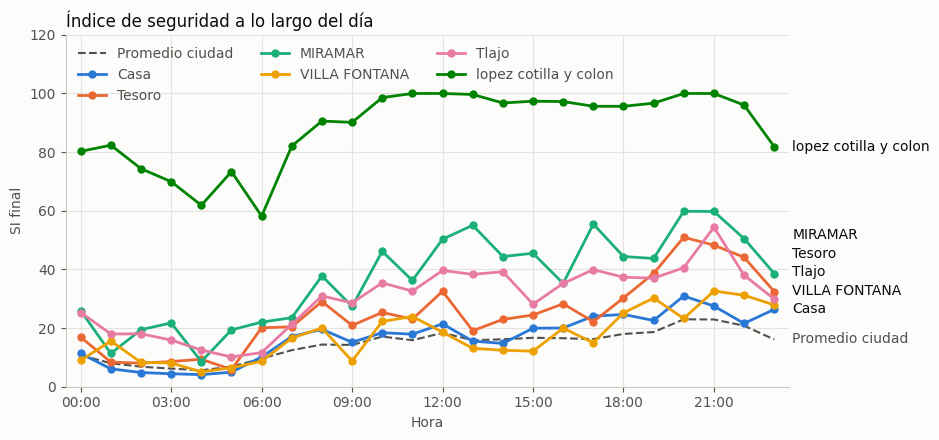

Casa: más segura 04:00 (SI 4.1), más riesgosa 20:00 (SI 30.9), promedio del día 16.8, 17 de 24 horas arriba del promedio de la ciudad
Tesoro: más segura 05:00 (SI 5.9), más riesgosa 20:00 (SI 51.0), promedio del día 24.6, 23 de 24 horas arriba del promedio de la ciudad
MIRAMAR: más segura 04:00 (SI 8.6), más riesgosa 20:00 (SI 59.8), promedio del día 36.8, 24 de 24 horas arriba del promedio de la ciudad
VILLA FONTANA: más segura 04:00 (SI 5.1), más riesgosa 21:00 (SI 32.6), promedio del día 17.3, 15 de 24 horas arriba del promedio de la ciudad
Tlajo: más segura 05:00 (SI 10.1), más riesgosa 21:00 (SI 54.4), promedio del día 29.9, 24 de 24 horas arriba del promedio de la ciudad
lopez cotilla y colon: más segura 06:00 (SI 58.2), más riesgosa 11:00 (SI 100.0), promedio del día 88.3, 24 de 24 horas arriba del promedio de la ciudad


In [13]:
# SI de cada lugar en las 24 horas, contra el promedio de la ciudad.
# Para comparar otro punto basta con agregarlo a `lugares` (hasta 8)
lugares = {
    "Casa": (20.615676, -103.416711),
    "Tesoro": (20.616993, -103.402352),
    "MIRAMAR": (20.636783, -103.448537),
    "VILLA FONTANA": (20.561920, -103.359527),
    "Tlajo": (20.475714, -103.449229),
    "lopez cotilla y colon": (20.674336, -103.347995)
}
# paleta categorica en orden fijo: el lugar n siempre usa el color n
colores = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
assert len(lugares) <= len(colores), "maximo 8 lugares por grafica"
horas = np.arange(24)
perfiles = {nombre: np.array([si_en(lat, lon, h) for h in horas])
            for nombre, (lat, lon) in lugares.items()}
perfil_ciudad = malla.groupby("hora")["SI_final"].mean()

fig, ax = plt.subplots(figsize=(9.5, 4.5), facecolor=FONDO)
ax.set_facecolor(FONDO)
ax.plot(horas, perfil_ciudad.values, color=TINTA_2, linewidth=1.5, linestyle="--",
        label="Promedio ciudad")
for (nombre, valores), color in zip(perfiles.items(), colores):
    ax.plot(horas, valores, color=color, linewidth=2, marker="o", markersize=5, label=nombre)

# etiquetas directas al final de cada linea, separadas si quedan encimadas
finales = sorted([(v[-1], n, TINTA) for n, v in perfiles.items()]
                 + [(perfil_ciudad.iloc[-1], "Promedio ciudad", TINTA_2)])
separacion = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.06
anterior = -np.inf
for valor, nombre, color in finales:
    y = max(valor, anterior + separacion)
    ax.annotate(nombre, (23, valor), xytext=(23.6, y), va="center", color=color, fontsize=10)
    anterior = y

ax.set_xticks(range(0, 24, 3), [f"{h:02d}:00" for h in range(0, 24, 3)])
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, max(max(v.max() for v in perfiles.values()), perfil_ciudad.max()) * 1.2)
ax.set_xlabel("Hora", color=TINTA_2)
ax.set_ylabel("SI final", color=TINTA_2)
ax.legend(frameon=False, loc="upper left", ncol=3, labelcolor=TINTA_2)
ax.grid(color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TINTA_2)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
for lado in ("left", "bottom"):
    ax.spines[lado].set_color("#c9c8c3")
ax.set_title("Índice de seguridad a lo largo del día", color=TINTA, fontsize=12, loc="left")
fig.tight_layout()
plt.show()

for nombre, valores in perfiles.items():
    arriba = horas[valores > perfil_ciudad.values]
    print(f"{nombre}: más segura {valores.argmin():02d}:00 (SI {valores.min():.1f}), "
          f"más riesgosa {valores.argmax():02d}:00 (SI {valores.max():.1f}), "
          f"promedio del día {valores.mean():.1f}, {len(arriba)} de 24 horas arriba del promedio de la ciudad")